In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Menghubungkan folder notebooks ke folder src
sys.path.append("..")
from src.estimator import mle_bernoulli, mle_poisson, beta_posterior

# Membaca dataset bersih hasil penarikan data
df = pd.read_csv("../data/clean/dataset.csv")
df['created_at'] = pd.to_datetime(df['created_at'])

print(f"Total baris data yang berhasil dibaca: {len(df)}")

Matplotlib is building the font cache; this may take a moment.


Total baris data yang berhasil dibaca: 2000


In [3]:
# --- 1. KALKULASI PARAMETER DISTRIBUSI POISSON ---
# Mengelompokkan data berdasarkan tanggal untuk menghitung jumlah issue harian
df['date_only'] = df['created_at'].dt.date
daily_counts = df.groupby('date_only').size().values

lambda_hat = mle_poisson(daily_counts)
print(f"Hasil Estimasi MLE Poisson (Rata-rata issue baru per hari / Lambda): {lambda_hat:.2f} issue/hari")

# --- 2. KALKULASI PARAMETER DISTRIBUSI BERNOULLI ---
# Memfilter data yang hanya berupa Pull Request (PR) dan mengambil status merge (1 = Merged, 0 = Closed tanpa merge)
pr_data = df[df['is_pull_request'] == True]['is_merged'].astype(int).values

p_hat = mle_bernoulli(pr_data)
print(f"Hasil Estimasi MLE Bernoulli (Peluang PR berhasil di-merge / p): {p_hat:.4f} atau {p_hat*100:.2f}%")

Hasil Estimasi MLE Poisson (Rata-rata issue baru per hari / Lambda): 15.38 issue/hari
Hasil Estimasi MLE Bernoulli (Peluang PR berhasil di-merge / p): 0.6450 atau 64.50%


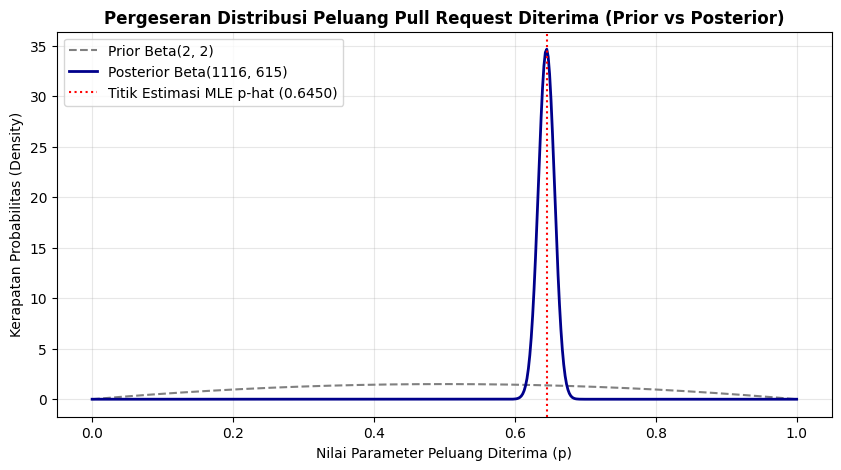

Update Parameter Fungsi Posterior: Alpha = 1116, Beta = 615


In [4]:
# --- 3. ANALISIS KONJUGASI BAYESIAN (BETA-BERNOULLI PRIOR TO POSTERIOR) ---
# Menentukan prior non-informatif awal (asumsi dasar sebelum melihat data nyata)
alpha_prior, beta_prior = 2, 2

# Menghitung parameter fungsi posterior menggunakan data historis asli
alpha_post, beta_post = beta_posterior(alpha_prior, beta_prior, pr_data)

# Proses plotting distribusi peluang
x = np.linspace(0, 1, 500)
y_prior = stats.beta.pdf(x, alpha_prior, beta_prior)
y_post = stats.beta.pdf(x, alpha_post, beta_post)

plt.figure(figsize=(10, 5))
plt.plot(x, y_prior, label=f'Prior Beta({alpha_prior}, {beta_prior})', linestyle='--', color='gray')
plt.plot(x, y_post, label=f'Posterior Beta({alpha_post}, {beta_post})', color='darkblue', linewidth=2)
plt.axvline(p_hat, color='red', linestyle=':', label=f'Titik Estimasi MLE p-hat ({p_hat:.4f})')

plt.title("Pergeseran Distribusi Peluang Pull Request Diterima (Prior vs Posterior)", fontsize=12, fontweight='bold')
plt.xlabel("Nilai Parameter Peluang Diterima (p)", fontsize=10)
plt.ylabel("Kerapatan Probabilitas (Density)", fontsize=10)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Update Parameter Fungsi Posterior: Alpha = {alpha_post}, Beta = {beta_post}")

## Penurunan Matematis Parameter Estimasi (Maximum Likelihood Estimation)

Bagian ini memuat pembuktian analitis penurunan rumus batas maksimum fungsi kemungkinan (Likelihood) berdasarkan landasan teori statistika komputasi.

### 1. Penurunan Rumus Parameter Distribusi Bernoulli

Variabel acak $X$ menyatakan status sebuah *Pull Request* dengan dua kemungkinan hasil: sukses di-integrate/merged ($x = 1$) atau ditolak/closed ($x = 0$). Berdasarkan acuan teori *Tsun (2020)* pada halaman 254, fungsi peluang dari $n$ sampel independen yang berdistribusi Bernoulli dapat dinyatakan ke dalam fungsi *Likelihood* berikut:

$$L(p) = \prod_{i=1}^{n} p^{x_i} (1-p)^{1-x_i} = p^{\sum_{i=1}^{n} x_i} (1-p)^{n - \sum_{i=1}^{n} x_i}$$

Untuk mempermudah operasi penurunan diferensial, fungsi diubah ke dalam bentuk logaritma natural (*Log-Likelihood*):

$$\ln L(p) = \ln \left( p^{\sum_{i=1}^{n} x_i} (1-p)^{n - \sum_{i=1}^{n} x_i} \right)$$

$$\ln L(p) = \left(\sum_{i=1}^{n} x_i\right) \ln(p) + \left(n - \sum_{i=1}^{n} x_i\right) \ln(1-p)$$

Nilai estimasi tertinggi didapatkan dengan mencari titik stasioner melalui turunan pertama terhadap parameter $p$ dan menyamakan hasilnya dengan nol $\left(\frac{d\ln L(p)}{dp} = 0\right)$:

$$\frac{d}{dp}\left[\left(\sum_{i=1}^{n} x_i\right) \ln(p) + \left(n - \sum_{i=1}^{n} x_i\right) \ln(1-p)\right] = 0$$

$$\frac{\sum_{i=1}^{n} x_i}{p} - \frac{n - \sum_{i=1}^{n} x_i}{1-p} = 0$$

$$\frac{\sum_{i=1}^{n} x_i}{p} = \frac{n - \sum_{i=1}^{n} x_i}{1-p}$$

$$\left(1-p\right) \sum_{i=1}^{n} x_i = p \left(n - \sum_{i=1}^{n} x_i\right)$$

$$\sum_{i=1}^{n} x_i - p\sum_{i=1}^{n} x_i = pn - p\sum_{i=1}^{n} x_i$$

$$\sum_{i=1}^{n} x_i = pn$$

$$\hat{p} = \frac{\sum_{i=1}^{n} x_i}{n}$$

**Interpretasi Nilai:** Rumus akhir di atas membuktikan secara matematis bahwa nilai estimasi peluang terbaik untuk parameter Bernoulli adalah rasio total jumlah sukses dibagi dengan ukuran sampel keseluruhan.

---

### 2. Penurunan Rumus Parameter Distribusi Poisson

Variabel acak $Y$ merepresentasikan kuantitas kemunculan peristiwa berupa *issue* atau *pull request* baru yang masuk dalam satuan interval waktu harian. Merujuk pada teori *Tsun (2020)* halaman 269, fungsi kerapatan peluang bersama untuk sampel independen yang berdistribusi Poisson dituliskan sebagai berikut:

$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda} \lambda^{x_i}}{x_i!} = \frac{e^{-n\lambda} \lambda^{\sum_{i=1}^{n} x_i}}{\prod_{i=1}^{n} x_i!}$$

Bentuk transformasi *Log-Likelihood* dari persamaan di atas adalah:

$$\ln L(\lambda) = \ln \left( \frac{e^{-n\lambda} \lambda^{\sum_{i=1}^{n} x_i}}{\prod_{i=1}^{n} x_i!} \right)$$

$$\ln L(\lambda) = -n\lambda + \left(\sum_{i=1}^{n} x_i\right) \ln(\lambda) - \ln\left(\prod_{i=1}^{n} x_i!\right)$$

Untuk memaksimalkan nilai kerapatan fungsi kemungkinan, dilakukan operasi penurunan parsial pertama terhadap parameter $\lambda$ dan menyamakan persamaannya dengan nol $\left(\frac{d\ln L(\lambda)}{d\lambda} = 0\right)$:

$$\frac{d}{d\lambda}\left[-n\lambda + \left(\sum_{i=1}^{n} x_i\right) \ln(\lambda) - \ln\left(\prod_{i=1}^{n} x_i!\right)\right] = 0$$

$$-n + \frac{\sum_{i=1}^{n} x_i}{\lambda} - 0 = 0$$

$$\frac{\sum_{i=1}^{n} x_i}{\lambda} = n$$

$$\hat{\lambda} = \frac{\sum_{i=1}^{n} x_i}{n} = \bar{X}$$

**Interpretasi Nilai:** Penurunan analitis di atas menegaskan bahwa estimator parameter tingkat rata-rata $\lambda$ yang paling optimum di dalam distribusi Poisson nilainya setara dengan nilai rata-rata hitung sampel (*sample mean*).

In [19]:
# Jalankan perintah penutup untuk memastikan semua proses hitung tuntas tanpa kendala
print("--- TAHAP ESTIMASI PARAMETER SELESAI ---")
print(f"Nilai akhir p-hat (Bernoulli) dan lambda-hat (Poisson) siap digunakan untuk tahap Inferensi dan Hipotesis berikutnya.")

--- TAHAP ESTIMASI PARAMETER SELESAI ---
Nilai akhir p-hat (Bernoulli) dan lambda-hat (Poisson) siap digunakan untuk tahap Inferensi dan Hipotesis berikutnya.
